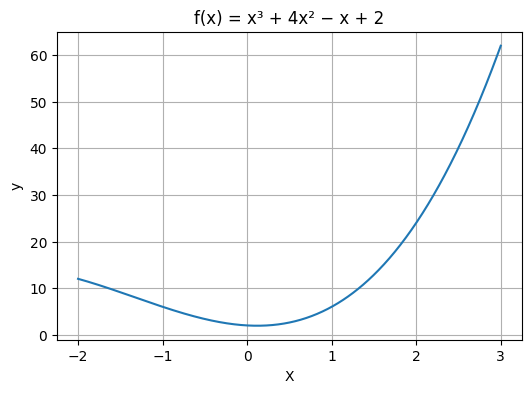

[4] → parameters: 13
Nodes: [4], Epochs: 50 → Train MSE: 78.4847, Test MSE: 87.5134
[4] → parameters: 13
Nodes: [4], Epochs: 100 → Train MSE: 61.1476, Test MSE: 65.5652
[4] → parameters: 13
Nodes: [4], Epochs: 150 → Train MSE: 24.9650, Test MSE: 28.7962
[4] → parameters: 13
Nodes: [4], Epochs: 200 → Train MSE: 39.3016, Test MSE: 45.1254
[4] → parameters: 13
Nodes: [4], Epochs: 300 → Train MSE: 25.1380, Test MSE: 29.0205
[4] → parameters: 13
Nodes: [4], Epochs: 400 → Train MSE: 251.6613, Test MSE: 275.7213
[4] → parameters: 13
Nodes: [4], Epochs: 500 → Train MSE: 2.4576, Test MSE: 2.8822
[8] → parameters: 25
Nodes: [8], Epochs: 50 → Train MSE: 63.5503, Test MSE: 70.6984
[8] → parameters: 25
Nodes: [8], Epochs: 100 → Train MSE: 81.3525, Test MSE: 91.4948
[8] → parameters: 25
Nodes: [8], Epochs: 150 → Train MSE: 18.3161, Test MSE: 20.7744
[8] → parameters: 25
Nodes: [8], Epochs: 200 → Train MSE: 16.0967, Test MSE: 18.1927
[8] → parameters: 25
Nodes: [8], Epochs: 300 → Train MSE: 5.8867, T

In [4]:
# Generate dataset for the range [-2,3] with 1000 sample
# Implementation comes this cell
import numpy as np

X = np.linspace(-2, 3, 1000).reshape(-1, 1) # input dataset
y = X**3 + 4*X**2 -X +2 # target dataset You can use ravel to flatten the array if needed: y = y.ravel()

# Plot the sample
# Implementation comes to this cell
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
#plt.scatter(X, y)
plt.plot(X, y)
plt.title("f(x) = x³ + 4x² − x + 2")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

# Shuffle the dataset and split it:
# training set 80%
# test set 20%
# Implementation comes this cell
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

# Define neural network using Keras Function API
# Input layer = 1 node
# 1-2 hidden layer = 4-8 nodes. Dense with 'relu' activation function in each hidden layer
# Cubic equation is nonlinear function, so we can't use linear activation function. 
# Output layer = 1 node (due to regression, only one node is enought in the output layer)

# Implementation comes this cell
# Print the structure of model: model.summary()

# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense

# inputs = Input(shape=(1,))
# hidden1 = Dense(4, activation='relu')(inputs)
# hidden2 = Dense(8, activation='relu')(hidden1)
# outputs = Dense(1)(hidden2)
# model = Model(inputs=inputs, outputs=outputs)

#model.summary()

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

def run_experiment(nodes, epochs):
    # Build model: nodes is a list, e.g. [8] or [4, 8]
    inputs = Input(shape=(1,))
    x = inputs
    for n in nodes:
        x = Dense(n, activation='relu')(x)
    outputs = Dense(1)(x)
    model = Model(inputs, outputs)
    print(nodes, "→ parameters:", model.count_params()) 

    # Train
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=0)

    # Evaluate
    train_mse = model.evaluate(X_train, y_train, verbose=0)
    test_mse = model.evaluate(X_test, y_test, verbose=0)
    print(f"Nodes: {nodes}, Epochs: {epochs} → Train MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}")

    # # Plot prediction vs true curve
    # y_pred = model.predict(X, verbose=0)
    # plt.figure(figsize=(6, 4))
    # plt.plot(X, y, label="True f(x)")
    # plt.plot(X, y_pred, label="Prediction", linestyle="--")
    # plt.title(f"Nodes {nodes}, Epochs {epochs}")
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    return model

# run_experiment([4, 8], 50)
# run_experiment([4, 8], 200)
# run_experiment([8, 8], 100)
# run_experiment([8], 200)     # one hidden layer

for nodes in [[4], [8], [4, 8], [8, 8]]:
    for epochs in [50, 100, 150, 200, 300, 400, 500]:
        run_experiment(nodes, epochs)